In [6]:
import pandas as pd
import sqlite3

df = pd.read_csv(r'D:\Github\Job_Finding_AI_Agent\data\Salary_data\archive\salaries.csv')

conn = sqlite3.connect('salaries.db')

# Push dataframe into SQLite as a table
df.to_sql('salaries', conn, if_exists='replace', index=False)

print("Done! Table created.")

print(df.head())



Done! Table created.
   work_year experience_level employment_type      job_title  salary  \
0       2025               EN              FT   Data Analist   65664   
1       2025               EN              FT   Data Analist   47652   
2       2025               EN              FT  Data Engineer  158113   
3       2025               EN              FT  Data Engineer   87795   
4       2025               EX              FT  Data Engineer  351410   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             EUR          69120                 NL             0   
1             EUR          50160                 NL             0   
2             USD         158113                 US             0   
3             USD          87795                 US             0   
4             USD         351410                 US             0   

  company_location company_size  
0               NL            M  
1               NL            M  
2               US           

In [20]:
query = """
    SELECT job_title, experience_level,ROUND(AVG(salary_in_usd)) AS salary
    FROM salaries
    where job_title = 'Data Engineer'
    GROUP BY experience_level
    ORDER BY salary DESC
"""

result = pd.read_sql_query(query, conn)
print(result)

       job_title experience_level    salary
0  Data Engineer               EX  200031.0
1  Data Engineer               SE  159654.0
2  Data Engineer               MI  126914.0
3  Data Engineer               EN   96006.0


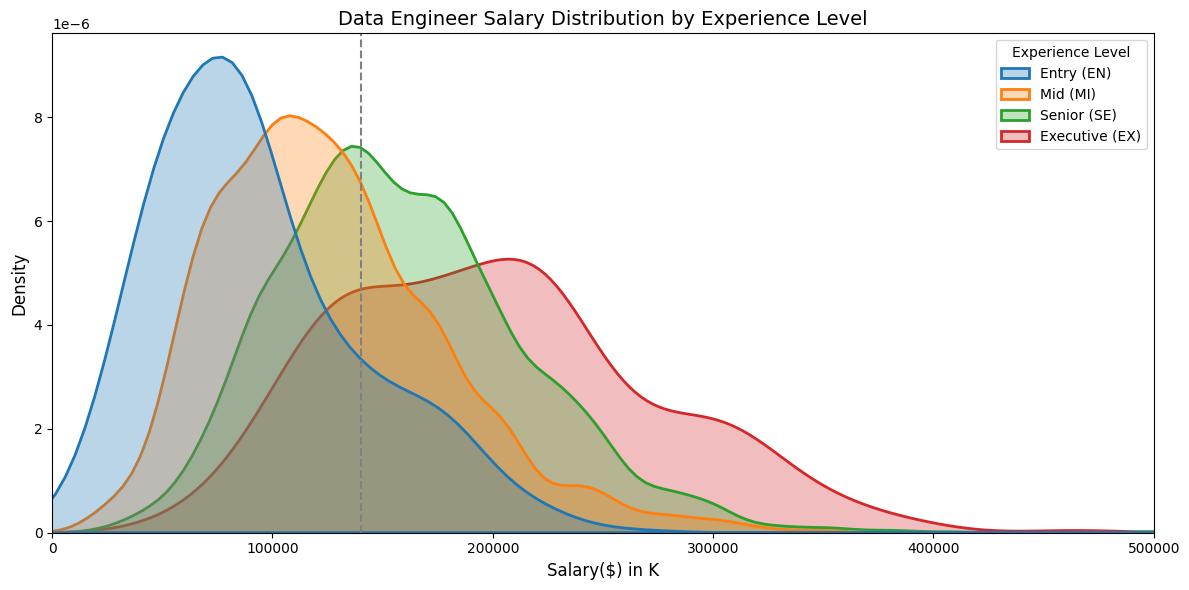

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

query = """
    SELECT experience_level, salary_in_usd AS salary
    FROM salaries
    WHERE job_title = 'Data Engineer'
"""
result = pd.read_sql_query(query, conn)

# Map codes to readable labels
level_order = ['EN', 'MI', 'SE', 'EX']
label_map = {'EN': 'Entry (EN)', 'MI': 'Mid (MI)', 'SE': 'Senior (SE)', 'EX': 'Executive (EX)'}
result['experience_label'] = result['experience_level'].map(label_map)

plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=result,
    x='salary',
    hue='experience_label',
    hue_order=[label_map[l] for l in level_order],
    fill=True,
    alpha=0.3,
    linewidth=2,
    common_norm=False
)

plt.title('Data Engineer Salary Distribution by Experience Level', fontsize=14)
plt.xlabel('Salary($) in K', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 500000)
plt.axvline(result['salary'].median(), color='gray', linestyle='--')

# ✅ Let seaborn handle the legend automatically — don't override it
# Add median label separately
plt.gca().get_legend().set_title('Experience Level')

plt.tight_layout()
plt.savefig('salary_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

In [26]:
import requests
import base64

# Read and encode image to base64
with open('salary_distribution.png', 'rb') as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')

# Send to local Ollama
response = requests.post(
    'http://localhost:11434/api/generate',
    json={
        "model": "llama3.2-vision",
        "prompt": """You are a data analyst. Analyze this salary distribution chart for Data Engineers.
        Please provide:
        1. Key observations about each experience level
        2. Salary ranges for each level
        3. Any interesting patterns you notice
        4. Actionable insights for someone job hunting as a Data Engineer
        """,
        "images": [image_data],
        "stream": False
    }
)

feedback = response.json()['response']
print(feedback)

The provided image is a density plot showing the distribution of salaries for Data Engineers across different experience levels. The plot is divided into five sections, each representing a specific experience level: Entry (EN), Mid (MI), Senior (SE), Executive (EX), and Experience Level (EL). The x-axis represents the salary range, while the y-axis represents the density of salaries.

**Key Observations:**

*   **Entry (EN) Level:** This level has the largest population of Data Engineers, with a salary range of $0-$100,000. The density plot shows a bell-shaped curve, indicating a normal distribution of salaries within this range.
*   **Mid (MI) Level:** This level has a slightly lower population of Data Engineers compared to the EN level, with a salary range of $100,000-$200,000. The density plot shows a slightly skewed distribution, with more Data Engineers earning lower salaries within this range.
*   **Senior (SE) Level:** This level has a smaller population of Data Engineers, with 